In [1]:
!pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.1 MB/s eta 0:00:00


In [2]:
import os
import math
import random
from pathlib import Path
from PIL import Image, ImageFilter, ImageEnhance

import cv2
import numpy as np
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torch.nn.functional as F
from torchvision.transforms import InterpolationMode

import gc
from tqdm import tqdm
import matplotlib.pyplot as plt

from transformers import SegformerForSemanticSegmentation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

img_dir = Path("/kaggle/input/datasets/karmagames/wrinkles-dataset/images_wrinkles/images_wrinkles")
mask_dir = Path("/kaggle/input/datasets/karmagames/wrinkles-dataset/manual_wrinkle_masks/manual_wrinkle_masks")

torch.backends.cudnn.benchmark = True
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


import segmentation_models_pytorch as smp
import random
from pathlib import Path
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode


IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


In [3]:
class RandomGamma:
    def __init__(self, gamma_range=(0.9, 1.1), p=0.3):
        self.gamma_range = gamma_range
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        gamma = random.uniform(*self.gamma_range)
        return TF.adjust_gamma(img, gamma)


class RandomGaussianBlur:
    def __init__(self, radius_range=(0.1, 0.6), p=0.2):
        self.radius_range = radius_range
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        radius = random.uniform(*self.radius_range)
        return img.filter(ImageFilter.GaussianBlur(radius))


class CLAHELabTransform:
    def __init__(self, clip_limit=1, tile_grid_size=(8, 8), p=0.25):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img

        img_np = np.array(img)
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)

        clahe = cv2.createCLAHE(
            clipLimit=self.clip_limit,
            tileGridSize=self.tile_grid_size
        )
        l = clahe.apply(l)

        lab = cv2.merge([l, a, b])
        out = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(out)


class WrinkleSegDatasetV2(Dataset):
    def __init__(self, pairs, img_size=1024, train=False, rgb=True):
        self.pairs = pairs
        self.train = train
        self.rgb = rgb
        self.img_size = img_size

        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

        self.color_aug = transforms.Compose([
            transforms.ColorJitter(
                brightness=0.20,
                contrast=0.20,
                saturation=0.08,
                hue=0.015
            ),
            RandomGamma(gamma_range=(0.80, 1.25), p=0.50),
            RandomGaussianBlur(radius_range=(0.1, 0.8), p=0.20),
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = Image.open(img_path)
        img = img.convert("RGB") if self.rgb else img.convert("L")
        mask = Image.open(mask_path).convert("L")

        # resize first
        img = TF.resize(img, [self.img_size, self.img_size], interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.img_size, self.img_size], interpolation=InterpolationMode.NEAREST)

        # geometric aug (same for image & mask)
        if self.train:
            if random.random() < 0.5:
                img = TF.hflip(img)
                mask = TF.hflip(mask)

            if random.random() < 0.15:
                img = TF.vflip(img)
                mask = TF.vflip(mask)

            angle = random.uniform(-10, 10)
            img = TF.rotate(img, angle, interpolation=InterpolationMode.BILINEAR)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)

            img = self.color_aug(img)

        x = TF.to_tensor(img)
        x = self.normalize(x)

        y = TF.to_tensor(mask)
        y = (y > 0.5).float()

        return x, y


def denormalize(img, mean, std):
    """
    img: tensor [C,H,W]
    """
    img = img.clone()
    for c in range(img.shape[0]):
        img[c] = img[c] * std[c] + mean[c]
    return img

def show_batch_with_masks(loader):
    imgs, masks = next(iter(loader))

    imgs = imgs.cpu()
    masks = masks.cpu()

    B = imgs.shape[0]

    fig, axes = plt.subplots(2, B, figsize=(3 * B, 6))

    for i in range(B):

        img = denormalize(imgs[i], IMAGENET_MEAN, IMAGENET_STD)

        img = img.numpy().transpose(1, 2, 0)
        mask = masks[i, 0].numpy()

        img = np.clip(img, 0, 1)

        axes[0, i].imshow(img)
        axes[0, i].axis("off")

        axes[1, i].imshow(mask, cmap="gray")
        axes[1, i].axis("off")

    axes[0, B // 2].set_title("Top: Images | Bottom: Masks")

    plt.tight_layout()
    plt.show()

In [4]:
image_paths = sorted(img_dir.glob("*.png"))

pairs = []

for img_path in image_paths:
    mask_path = mask_dir / img_path.name
    
    if mask_path.exists():
        pairs.append((img_path, mask_path))
    else:
        print(f"⚠ Mask not found for {img_path.name}")

print(f"Recovered {len(pairs)} pairs successfully.")
pairs[:3]

Recovered 1000 pairs successfully.


[(PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/images_wrinkles/images_wrinkles/00001.png'),
  PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/manual_wrinkle_masks/manual_wrinkle_masks/00001.png')),
 (PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/images_wrinkles/images_wrinkles/00011.png'),
  PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/manual_wrinkle_masks/manual_wrinkle_masks/00011.png')),
 (PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/images_wrinkles/images_wrinkles/00016.png'),
  PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/manual_wrinkle_masks/manual_wrinkle_masks/00016.png'))]

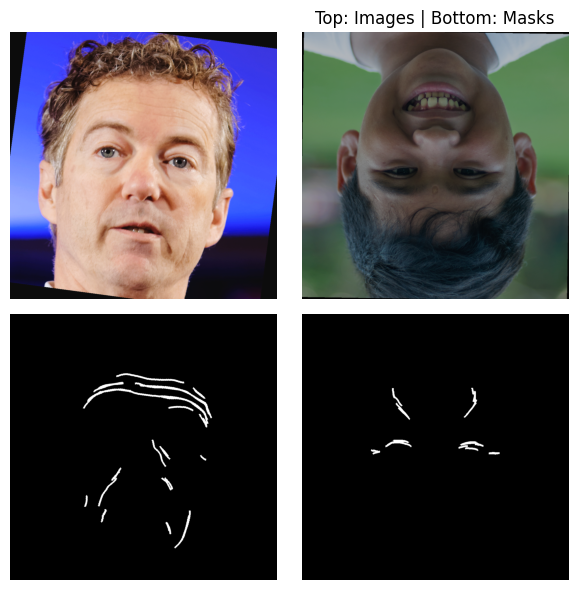

train/dev/test: 400 50 50


In [5]:
IMG_SIZE = 1024
BATCH_SIZE = 2
NUM_EPOCHS = 45

train_pairs, temp_pairs = train_test_split(
    pairs, test_size=0.2, random_state=42, shuffle=True
)

dev_pairs, test_pairs = train_test_split(
    temp_pairs, test_size=0.5, random_state=42, shuffle=True
)

ds_tr = WrinkleSegDatasetV2(train_pairs, img_size=IMG_SIZE, train=True, rgb=True)
ds_dev = WrinkleSegDatasetV2(dev_pairs, img_size=IMG_SIZE, train=False, rgb=True)
ds_te = WrinkleSegDatasetV2(test_pairs, img_size=IMG_SIZE, train=False, rgb=True)

train_loader = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(ds_dev, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(ds_te, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

show_batch_with_masks(train_loader)

print("train/dev/test:", len(train_loader), len(val_loader), len(test_loader))

In [6]:

bce_loss = nn.BCEWithLogitsLoss()

def dice_loss(logits, targets, smooth=1.0):
    probs = torch.sigmoid(logits)

    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (probs * targets).sum(dim=1)
    dice = (2.0 * intersection + smooth) / (
        probs.sum(dim=1) + targets.sum(dim=1) + smooth
    )

    return 1.0 - dice.mean()


def bce_dice_loss(logits, targets):
    return bce_loss(logits, targets) + dice_loss(logits, targets)


def batch_iou_dice(logits, targets, threshold=0.5, eps=1e-8):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (preds.sum(dim=1) + targets.sum(dim=1) + eps)

    return iou.mean().item(), dice.mean().item()


def train_one_epoch(model, loader, optimizer, device, ep, epochs):
    model.train()

    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0
    
    pbar = tqdm(loader, desc=f"epoch {ep}/{epochs}", leave=False)

    for imgs, masks in pbar:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        logits = model(imgs)
        loss = bce_dice_loss(logits, masks)

        loss.backward()
        optimizer.step()

        iou, dice = batch_iou_dice(logits.detach(), masks)

        running_loss += loss.item()
        running_iou += iou
        running_dice += dice

    n = len(loader)
    return {
        "loss": running_loss / n,
        "iou": running_iou / n,
        "dice": running_dice / n,
    }


@torch.no_grad()
def validate_one_epoch(model, loader, device, threshold=0.5, eps=1e-8):
    model.eval()

    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0

    # для глобальних метрик
    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0
    total_tn = 0.0

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        logits = model(imgs)
        loss = bce_dice_loss(logits, masks)

        # базові метрики
        iou, dice = batch_iou_dice(logits, masks)

        running_loss += loss.item()
        running_iou += iou
        running_dice += dice

        # ===== нове: pixel-level метрики =====
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

        tp = (preds * masks).sum().item()
        fp = (preds * (1 - masks)).sum().item()
        fn = ((1 - preds) * masks).sum().item()
        tn = ((1 - preds) * (1 - masks)).sum().item()

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_tn += tn

    n = len(loader)

    # ===== фінальні метрики =====
    accuracy = (total_tp + total_tn) / (total_tp + total_tn + total_fp + total_fn + eps)
    precision = total_tp / (total_tp + total_fp + eps)
    recall = total_tp / (total_tp + total_fn + eps)

    return {
        "loss": running_loss / n,
        "iou": running_iou / n,
        "dice": running_dice / n,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
    }


@torch.no_grad()
def predict_batch(model, loader, device, threshold=0.5):
    model.eval()
    imgs, masks = next(iter(loader))

    imgs = imgs.to(device)
    masks = masks.to(device)

    logits = model(imgs)
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    return imgs.cpu(), masks.cpu(), logits.cpu(), preds.cpu(), probs.cpu()


def single_iou_dice(logit, target, threshold=0.5, eps=1e-8):
    """
    logit: tensor [1, H, W] або [H, W]
    target: tensor [1, H, W] або [H, W]
    """
    if logit.ndim == 3:
        logit = logit.squeeze(0)
    if target.ndim == 3:
        target = target.squeeze(0)

    prob = torch.sigmoid(logit)
    pred = (prob > threshold).float()

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (pred.sum() + target.sum() + eps)

    return iou.item(), dice.item(), prob.cpu().numpy()

def show_predictions_overlay(imgs, masks, logits, n=4, threshold=0.5, alpha=0.45):
    import numpy as np
    import matplotlib.pyplot as plt

    def make_error_overlay(img, pred, gt, alpha=0.45):
        pred = pred.astype(bool)
        gt = gt.astype(bool)

        tp = pred & gt
        fp = pred & (~gt)
        fn = (~pred) & gt

        overlay = img.copy()

        # TP → green
        overlay[tp] = (1 - alpha) * overlay[tp] + alpha * np.array([0.0, 1.0, 0.0])

        # FP → red
        overlay[fp] = (1 - alpha) * overlay[fp] + alpha * np.array([1.0, 0.0, 0.0])

        # FN → blue
        overlay[fn] = (1 - alpha) * overlay[fn] + alpha * np.array([0.0, 0.0, 1.0])

        return np.clip(overlay, 0, 1)

    n = min(n, imgs.shape[0])
    fig, ax = plt.subplots(n, 4, figsize=(16, 4 * n))

    if n == 1:
        ax = np.expand_dims(ax, axis=0)

    for i in range(n):
        img = imgs[i].cpu().numpy().transpose(1, 2, 0)
        img = np.clip(img, 0, 1)

        gt = masks[i, 0].cpu().numpy()

        # 👇 використовуємо твою функцію
        iou, dice, prob = single_iou_dice(logits[i], masks[i], threshold=threshold)

        pred = (prob > threshold).astype(np.float32)

        overlay = make_error_overlay(img, pred, gt, alpha=alpha)

        # Image
        ax[i, 0].imshow(img)
        ax[i, 0].set_title("Image")
        ax[i, 0].axis("off")

        # GT
        ax[i, 1].imshow(gt, cmap="gray")
        ax[i, 1].set_title("Ground Truth")
        ax[i, 1].axis("off")

        # Prediction
        ax[i, 2].imshow(pred, cmap="gray")
        ax[i, 2].set_title(f"Pred\nDice={dice:.3f} IoU={iou:.3f}")
        ax[i, 2].axis("off")

        # Overlay
        ax[i, 3].imshow(overlay)
        ax[i, 3].set_title("Overlay\nGreen=TP Red=FP Blue=FN")
        ax[i, 3].axis("off")

    plt.tight_layout()
    plt.show()

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )
        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)

        # safety на випадок непарних розмірів картинки
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(
                x,
                size=skip.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=(64, 128, 256, 512)):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, features[0])
        self.enc2 = DownBlock(features[0], features[1])
        self.enc3 = DownBlock(features[1], features[2])
        self.enc4 = DownBlock(features[2], features[3])

        self.bottleneck = DownBlock(features[3], features[3] * 2)

        self.dec4 = UpBlock(features[3] * 2, features[3], features[3])
        self.dec3 = UpBlock(features[3], features[2], features[2])
        self.dec2 = UpBlock(features[2], features[1], features[1])
        self.dec1 = UpBlock(features[1], features[0], features[0])

        self.out_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)

        x = self.bottleneck(s4)

        x = self.dec4(x, s4)
        x = self.dec3(x, s3)
        x = self.dec2(x, s2)
        x = self.dec1(x, s1)

        return self.out_conv(x)


model = SimpleUNet(
    in_channels=3,
    out_channels=1,
    features=(64, 128, 256, 512)
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50
)


Device: cuda


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

In [ ]:
num_epochs = 50
best_val_dice = -1.0

history = {
    "train_loss": [],
    "train_iou": [],
    "train_dice": [],
    "val_loss": [],
    "val_iou": [],
    "val_dice": [],
}

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, optimizer, device, epoch, num_epochs)
    val_metrics = validate_one_epoch(model, val_loader, device)

    scheduler.step()

    history["train_loss"].append(train_metrics["loss"])
    history["train_iou"].append(train_metrics["iou"])
    history["train_dice"].append(train_metrics["dice"])

    history["val_loss"].append(val_metrics["loss"])
    history["val_iou"].append(val_metrics["iou"])
    history["val_dice"].append(val_metrics["dice"])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"train_loss={train_metrics['loss']:.4f}, train_iou={train_metrics['iou']:.4f}, train_dice={train_metrics['dice']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f}, val_iou={val_metrics['iou']:.4f}, val_dice={val_metrics['dice']:.4f}"
    )

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        torch.save(model.state_dict(), "best_simple_unet.pth")
        print("Saved best model.")


Epoch [1/50] | train_loss=0.9129, train_iou=0.2648, train_dice=0.3959 | val_loss=0.5607, val_iou=0.3892, val_dice=0.5476
Saved best model.


Epoch [2/50] | train_loss=0.4825, train_iou=0.4112, train_dice=0.5754 | val_loss=0.4498, val_iou=0.4305, val_dice=0.5931
Saved best model.


Epoch [3/50] | train_loss=0.4419, train_iou=0.4324, train_dice=0.5973 | val_loss=0.4466, val_iou=0.4296, val_dice=0.5923


Epoch [4/50] | train_loss=0.4263, train_iou=0.4444, train_dice=0.6093 | val_loss=0.4296, val_iou=0.4435, val_dice=0.6058
Saved best model.


Epoch [5/50] | train_loss=0.4095, train_iou=0.4598, train_dice=0.6243 | val_loss=0.4131, val_iou=0.4588, val_dice=0.6204
Saved best model.


Epoch [6/50] | train_loss=0.4069, train_iou=0.4616, train_dice=0.6257 | val_loss=0.4273, val_iou=0.4452, val_dice=0.6065


epoch 6/50:  38%|███▊      | 151/400 [02:55<04:54,  1.18s/it]